# **Convolución 1D**

Este cuaderno explora las capas convolucionales 1D.

Ejecuta las celdas en orden. En varios lugares verás la palabra "TAREA": sigue esas instrucciones, anticipa qué ocurrirá o escribe el código necesario para completar las funciones.


**Nota**

En estas funciones usaremos la convención habitual de dilatación: una dilatación de 1 aplica el filtro sobre elementos contiguos; una dilatación de 2 deja un espacio entre elementos consecutivos del filtro.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#! Define una señal a la que aplicaremos convolución
x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.3, 9.9, 10.3, 3.2, 3.4, 3.3, 3.1]

#! Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
plt.show()

# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.

#!DONE...
def conv_3_1_1_zp(x_in, omega):
    x_out = np.zeros_like(x_in)

    for i in range(len(x_in)):
        for k in range(3):
            idx = i + k - 1
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]

    return x_out

    Corresponde a la formula:
                                            y[i]=ω0​x[i−1]+ω1​x[i]+ω2​x[i+1]

La suma de la salida es 71.1, debe ser 71.1


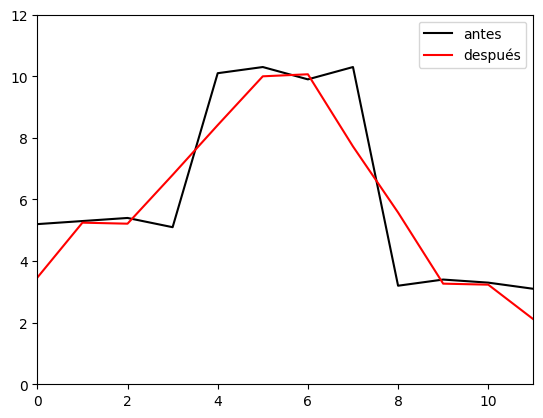

In [ ]:

#* Ahora veamos qué tipo de operaciones puede hacer una convolución.
#*Primero puede promediar valores cercanos y suavizar la función:

omega = [0.33,0.33,0.33]
h = conv_3_1_1_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h):3.3}, debe ser 71.1")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la función roja es una versión suavizada de la negra, porque promedia valores adyacentes. Sin embargo, las primeras y últimas salidas son bastante menores que la curva original. Asegúrate de entender por qué.<br><br>

Con pesos diferentes, la convolución puede detectar cambios bruscos en la función:

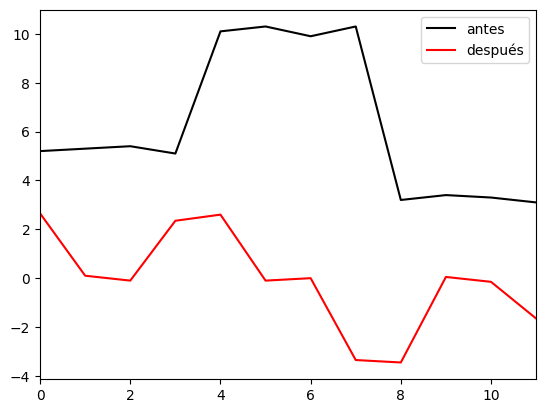

In [3]:
omega = [-0.5,0,0.5]
h2 = conv_3_1_1_zp(x, omega)

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h2, 'r-',label='después')
ax.set_xlim(0,11)
# ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la convolución produce un pico donde la función original sube y un valle donde baja. Es aproximadamente cero donde la función es localmente plana; por eso esta convolución aproxima una derivada. <br><br>

Ahora definamos algunas convoluciones con distintos parámetros.

In [ ]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 2 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.

#! DONE...
def conv_3_2_1_zp(x_in, omega):
    x_out = np.zeros(int(np.ceil(len(x_in)/2)))

    for i in range(len(x_out)):
        pos = i * 2
        for k in range(3):
            idx = pos + k - 1
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]

    return x_out


omega = [0.33,0.33,0.33]
h3 = conv_3_2_1_zp(x, omega)

# Si lo hiciste bien, la longitud de salida debe ser seis y debe
# contener uno de cada dos valores de la convolución original con paso 1
print(h)
print(h3)

In [ ]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 5, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.

#!DONE...
def conv_5_1_1_zp(x_in, omega):
    x_out = np.zeros_like(x_in)

    for i in range(len(x_in)):
        for k in range(5):
            idx = i + k - 2
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]

    return x_out


omega2 = [0.2, 0.2, 0.2, 0.2, 0.2]
h4 = conv_5_1_1_zp(x, omega2)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h4):3.3}, debe ser 69.6")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h4, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

In [ ]:
# Finalmente, definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 2.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.

#!DONE....

def conv_3_1_2_zp(x_in, omega):
    x_out = np.zeros_like(x_in)

    for i in range(len(x_in)):
        for k in range(3):
            idx = i + (k - 1) * 2
            if 0 <= idx < len(x_in):
                x_out[i] += omega[k] * x_in[idx]

    return x_out

omega = [0.33,0.33,0.33]
h5 = conv_3_1_2_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h5):3.3}, debe ser 68.3")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h5, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Finalmente, representemos las convoluciones como matrices completas y comprobemos que obtenemos el mismo resultado.

In [ ]:
# Calcula la matriz de convolución

#! DONE...
def get_conv_mat_3_1_1_zp(n_out, omega):
    omega_mat = np.zeros((n_out, n_out))

    for i in range(n_out):
        for k in range(3):
            idx = i + k - 1
            if 0 <= idx < n_out:
                omega_mat[i, idx] = omega[k]

    return omega_mat
  
# Ejecuta la convolución original
omega = np.array([-1.0,0.5,-0.2])
h6 = conv_3_1_1_zp(x, omega)
print(h6)

# Si lo hiciste bien, deberías obtener la misma respuesta
omega_mat = get_conv_mat_3_1_1_zp(len(x), omega)
h7 = np.matmul(omega_mat, x)
print(h7)

TAREA: ¿Qué esperas que ocurra si aplicamos dos veces la última convolución? ¿Se puede representar como una sola convolución? Si es así, ¿cuál sería?

    Al aplicar dos veces la misma convolución, el efecto del filtro se acumula sobre la señal. 
    
    En lugar de realizar dos convoluciones por separado, es posible representarlas como una sola convolución utilizando un nuevo kernel equivalente. Este nuevo kernel se obtiene al convolucionar el filtro consigo mismo. Para el filtro [-1.0, 0.5, -0.2], el kernel equivalente es:

### [1.0, -1.0, 0.65, -0.2, 0.04]

    Por lo tanto, aplicar dos veces la convolución de tamaño 3 es equivalente a aplicar una sola convolución con un kernel de tamaño 5 formado por esos nuevos coeficientes.